ML4SCI HEPSIM: GSoC 2026 Evaluation Task
Objective: To analyze quark and gluon jets by extracting kinematic observables, performing Lorentz boosts, and training a machine learning classifier to evaluate feature representations.

Approach & Findings: In this notebook, I implemented a highly optimized, fully vectorized NumPy data pipeline to process 100,000 jets without standard loops. I calculated Lab-frame features (Jet Mass, Width, and pT Dispersion) by masking zero-padded constituents, and subsequently boosted the four-momenta into the Jet Center-of-Mass (CM) frame. Finally, I trained Random Forest classifiers to distinguish quark from gluon jets using both reference frames.

The classifiers achieved identical predictive power (AUC ≈ 0.855 in both frames). This physically aligns with the extraction data: the most highly discriminating features for Quark/Gluon tagging specifically Constituent Multiplicity and Invariant Jet Mass (CM energy) are Lorentz-invariant. Therefore, boosting to the rest frame injects no new distinguishing information into the system.

# Quark vs Gluon Jet Analysis

This notebook analyzes jet constituents from the QG_jets.npz dataset, comparing quark and gluon jets.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# Set up high-quality plot style
plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['figure.dpi'] = 120
mpl.rcParams['font.size'] = 12

# Load the data
data = np.load('QG_jets.npz')
X = data['X']  # Shape: (n_jets, n_constituents, 4) - features: (pT, y, phi, pdgid)
y = data['y']  # Labels: 0 = gluon, 1 = quark

print(f"Dataset loaded successfully!")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Number of jets: {X.shape[0]}")
print(f"Max constituents per jet: {X.shape[1]}")
print(f"Features: pT, y, phi, pdgid")
print(f"\nLabel distribution:")
print(f"  Gluon jets (label=0): {np.sum(y == 0)}")
print(f"  Quark jets (label=1): {np.sum(y == 1)}")

Dataset loaded successfully!
X shape: (100000, 139, 4)
y shape: (100000,)
Number of jets: 100000
Max constituents per jet: 139
Features: pT, y, phi, pdgid

Label distribution:
  Gluon jets (label=0): 50000
  Quark jets (label=1): 50000


## Total Non-Zero Constituents Analysis

Calculate the total number of non-zero (valid) constituents across all quark and gluon jets by masking zero-padding (pT > 0).

In [13]:
# Extract pT values (first feature)
pT = X[:, :, 0]  # Shape: (n_jets, n_constituents)

# Mask zero-padding: valid constituents have pT > 0
valid_constituents = pT > 0

# Separate quark and gluon jets
quark_mask = y == 1
gluon_mask = y == 0

# Calculate total non-zero constituents for each jet type
quark_nonzero = np.sum(valid_constituents[quark_mask])
gluon_nonzero = np.sum(valid_constituents[gluon_mask])

print("=" * 50)
print("Total Non-Zero Constituents")
print("=" * 50)
print(f"Quark jets:  {quark_nonzero:,} valid constituents")
print(f"Gluon jets:  {gluon_nonzero:,} valid constituents")
print(f"\nTotal:       {quark_nonzero + gluon_nonzero:,} valid constituents")

Total Non-Zero Constituents
Quark jets:  1,669,999 valid constituents
Gluon jets:  2,660,906 valid constituents

Total:       4,330,905 valid constituents


## Constituent Multiplicity Histogram

Calculate the number of valid particles (constituents with pT > 0) per jet and plot overlapping histograms comparing quark and gluon jets.

Constituent Multiplicity Statistics:
----------------------------------------
Quark jets:  Mean = 33.40, Std = 13.34
Gluon jets:  Mean = 53.22, Std = 15.76


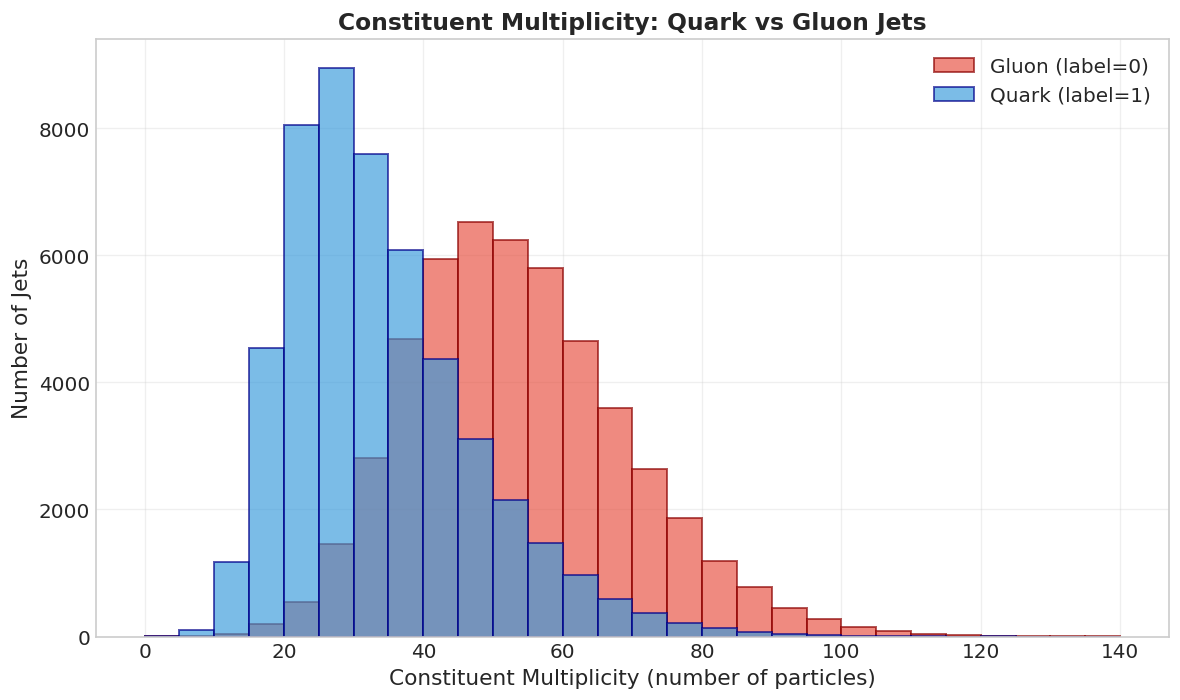


Histogram saved as 'constituent_multiplicity.png'


In [14]:
# Calculate constituent multiplicity (number of valid particles per jet)
multiplicity = np.sum(valid_constituents, axis=1)
quark_multiplicity = multiplicity[quark_mask]
gluon_multiplicity = multiplicity[gluon_mask]

print("Constituent Multiplicity Statistics:")
print("-" * 40)
print(f"Quark jets:  Mean = {np.mean(quark_multiplicity):.2f}, Std = {np.std(quark_multiplicity):.2f}")
print(f"Gluon jets:  Mean = {np.mean(gluon_multiplicity):.2f}, Std = {np.std(gluon_multiplicity):.2f}")

# Plot overlapping histogram
fig, ax = plt.subplots(figsize=(10, 6))

# Create histogram with high contrast colors
bins = np.arange(0, np.max(multiplicity) + 5, 5)

ax.hist(gluon_multiplicity, bins=bins, alpha=0.65, label='Gluon (label=0)', 
        color='#E74C3C', edgecolor='darkred', linewidth=1.2)
ax.hist(quark_multiplicity, bins=bins, alpha=0.65, label='Quark (label=1)', 
        color='#3498DB', edgecolor='darkblue', linewidth=1.2)

ax.set_xlabel('Constituent Multiplicity (number of particles)', fontsize=13)
ax.set_ylabel('Number of Jets', fontsize=13)
ax.set_title('Constituent Multiplicity: Quark vs Gluon Jets', fontsize=14, fontweight='bold')
ax.legend(fontsize=12, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('constituent_multiplicity.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nHistogram saved as 'constituent_multiplicity.png'")

## Leading Constituent Analysis

Find the leading (highest pT) constituent in each jet and plot distributions for:
1. Leading pT
2. Rapidity (y)

In [15]:
# Find leading (highest pT) constituent in each jet
# pT is the first feature (index 0)
# Use argmax to find index of highest pT, then extract that constituent

pT_values = X[:, :, 0]  # All pT values
y_rapidity = X[:, :, 1]  # Rapidity (y)

# Find indices of leading pT constituent for each jet
leading_indices = np.argmax(pT_values, axis=1)

# Get the leading pT and rapidity for each jet
n_jets = X.shape[0]
leading_pT = np.array([pT_values[i, leading_indices[i]] for i in range(n_jets)])
leading_y = np.array([y_rapidity[i, leading_indices[i]] for i in range(n_jets)])

# Separate by jet type
quark_leading_pT = leading_pT[quark_mask]
gluon_leading_pT = leading_pT[gluon_mask]
quark_leading_y = leading_y[quark_mask]
gluon_leading_y = leading_y[gluon_mask]

print("Leading Constituent Statistics:")
print("-" * 40)
print(f"Quark leading pT:  Mean = {np.mean(quark_leading_pT):.2f} GeV, Std = {np.std(quark_leading_pT):.2f}")
print(f"Gluon leading pT:  Mean = {np.mean(gluon_leading_pT):.2f} GeV, Std = {np.std(gluon_leading_pT):.2f}")
print(f"\nQuark leading y:   Mean = {np.mean(quark_leading_y):.3f}, Std = {np.std(quark_leading_y):.3f}")
print(f"Gluon leading y:   Mean = {np.mean(gluon_leading_y):.3f}, Std = {np.std(gluon_leading_y):.3f}")

Leading Constituent Statistics:
----------------------------------------
Quark leading pT:  Mean = 148.64 GeV, Std = 71.58
Gluon leading pT:  Mean = 90.77 GeV, Std = 44.11

Quark leading y:   Mean = -0.000, Std = 0.859
Gluon leading y:   Mean = 0.006, Std = 0.884


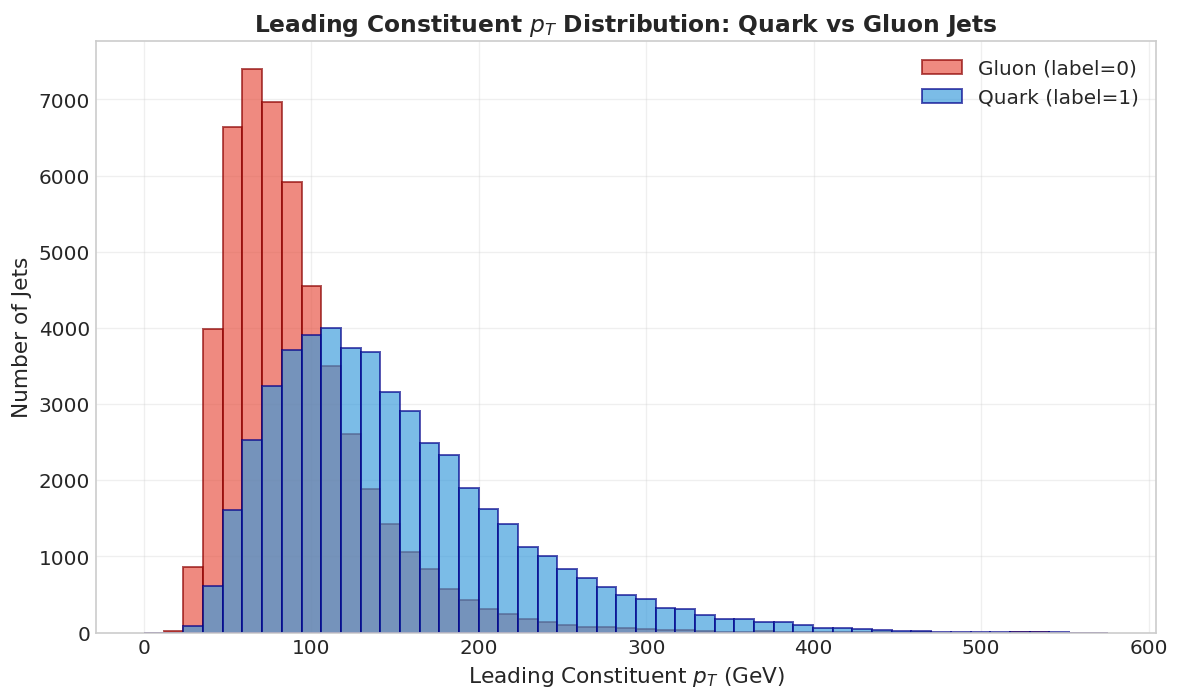


Leading pT histogram saved as 'leading_pT_distribution.png'


In [16]:
# Plot histograms for leading pT distribution
fig, ax = plt.subplots(figsize=(10, 6))

bins_pT = np.linspace(0, np.max(leading_pT) * 1.05, 50)

ax.hist(gluon_leading_pT, bins=bins_pT, alpha=0.65, label='Gluon (label=0)', 
        color='#E74C3C', edgecolor='darkred', linewidth=1.2)
ax.hist(quark_leading_pT, bins=bins_pT, alpha=0.65, label='Quark (label=1)', 
        color='#3498DB', edgecolor='darkblue', linewidth=1.2)

ax.set_xlabel('Leading Constituent $p_T$ (GeV)', fontsize=13)
ax.set_ylabel('Number of Jets', fontsize=13)
ax.set_title('Leading Constituent $p_T$ Distribution: Quark vs Gluon Jets', fontsize=14, fontweight='bold')
ax.legend(fontsize=12, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('leading_pT_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nLeading pT histogram saved as 'leading_pT_distribution.png'")

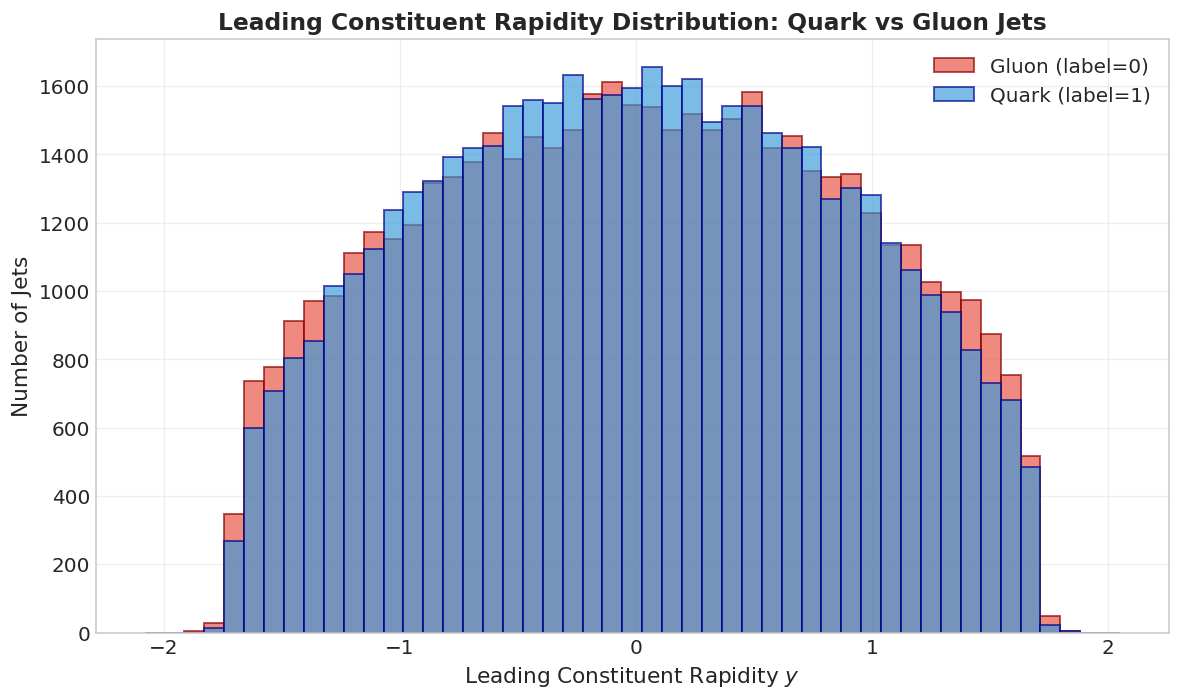


Leading rapidity histogram saved as 'leading_rapidity_distribution.png'


In [17]:
# Plot histograms for leading rapidity (y) distribution
fig, ax = plt.subplots(figsize=(10, 6))

bins_y = np.linspace(np.min(leading_y) * 1.1, np.max(leading_y) * 1.1, 50)

ax.hist(gluon_leading_y, bins=bins_y, alpha=0.65, label='Gluon (label=0)', 
        color='#E74C3C', edgecolor='darkred', linewidth=1.2)
ax.hist(quark_leading_y, bins=bins_y, alpha=0.65, label='Quark (label=1)', 
        color='#3498DB', edgecolor='darkblue', linewidth=1.2)

ax.set_xlabel('Leading Constituent Rapidity $y$', fontsize=13)
ax.set_ylabel('Number of Jets', fontsize=13)
ax.set_title('Leading Constituent Rapidity Distribution: Quark vs Gluon Jets', fontsize=14, fontweight='bold')
ax.legend(fontsize=12, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('leading_rapidity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nLeading rapidity histogram saved as 'leading_rapidity_distribution.png'")

## Summary

This notebook has analyzed the QG_jets dataset comparing quark and gluon jets:

1. **Total Non-Zero Constituents**: Calculated the total number of valid (pT > 0) particles for each jet type
2. **Constituent Multiplicity**: Plotted overlapping histogram showing the number of particles per jet
3. **Leading Constituent pT**: Plotted the distribution of the highest-pT particle in each jet
4. **Leading Constituent Rapidity**: Plotted the rapidity distribution of the leading particle

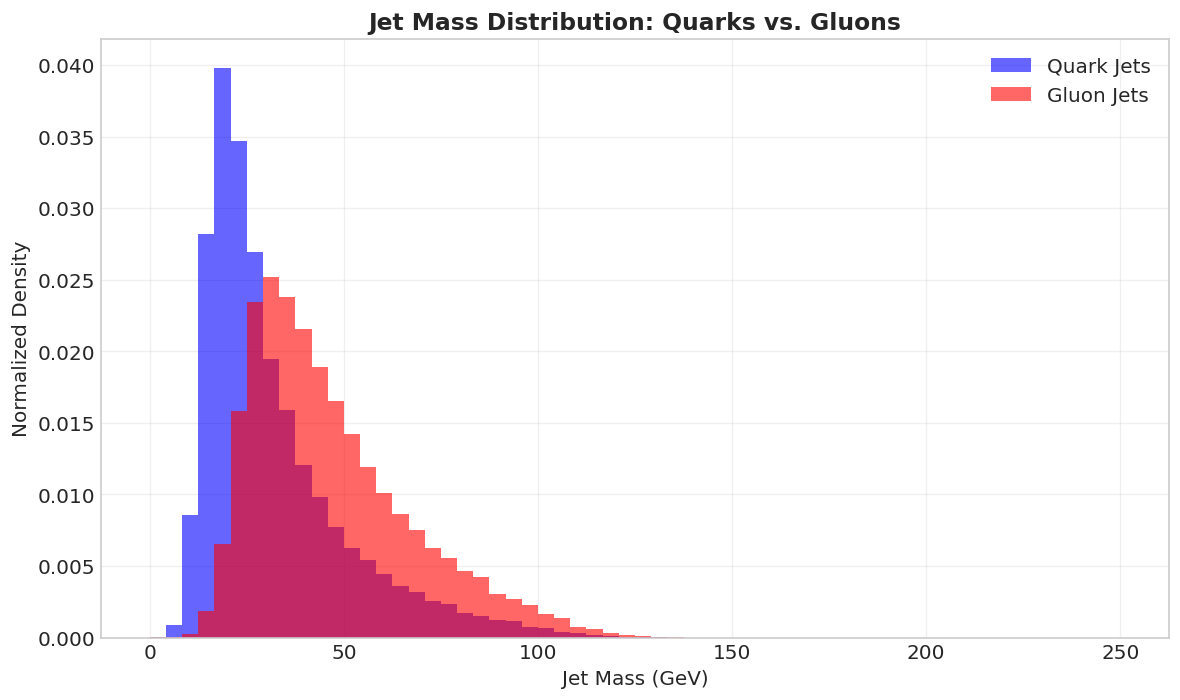

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming X and y were loaded in your first cell. 
# X shape: (100000, 139, 4) -> features: (pT, y, phi, pdgid)
pt = X[:, :, 0]
rap = X[:, :, 1]
phi = X[:, :, 2]

# Create a mask to ignore the zero-padded empty constituents
mask = pt > 0

# --- 1. Four-Momentum Conversion ---
# Calculate constituent momenta
px = pt * np.cos(phi)
py = pt * np.sin(phi)
pz = pt * np.sinh(rap)
e = pt * np.cosh(rap)

# Sum across the constituents (axis=1) applying the mask to get Jet 4-momentum
Px_jet = np.sum(px * mask, axis=1)
Py_jet = np.sum(py * mask, axis=1)
Pz_jet = np.sum(pz * mask, axis=1)
E_jet = np.sum(e * mask, axis=1)

# --- 2. Jet Mass Calculation ---
# m_J = sqrt(max(0, E^2 - P^2))
P2_jet = Px_jet**2 + Py_jet**2 + Pz_jet**2
m2_jet = E_jet**2 - P2_jet
# Use np.maximum to prevent negative roots due to floating point precision
m_jet = np.sqrt(np.maximum(0, m2_jet))

# --- Plotting ---
quark_mask = (y == 1)
gluon_mask = (y == 0)

plt.figure(figsize=(10, 6))
# Using density=True normalizes the histograms so they can be compared properly
plt.hist(m_jet[quark_mask], bins=60, range=(0, 250), alpha=0.6, color='blue', label='Quark Jets', density=True)
plt.hist(m_jet[gluon_mask], bins=60, range=(0, 250), alpha=0.6, color='red', label='Gluon Jets', density=True)

plt.xlabel('Jet Mass (GeV)', fontsize=12)
plt.ylabel('Normalized Density', fontsize=12)
plt.title('Jet Mass Distribution: Quarks vs. Gluons', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

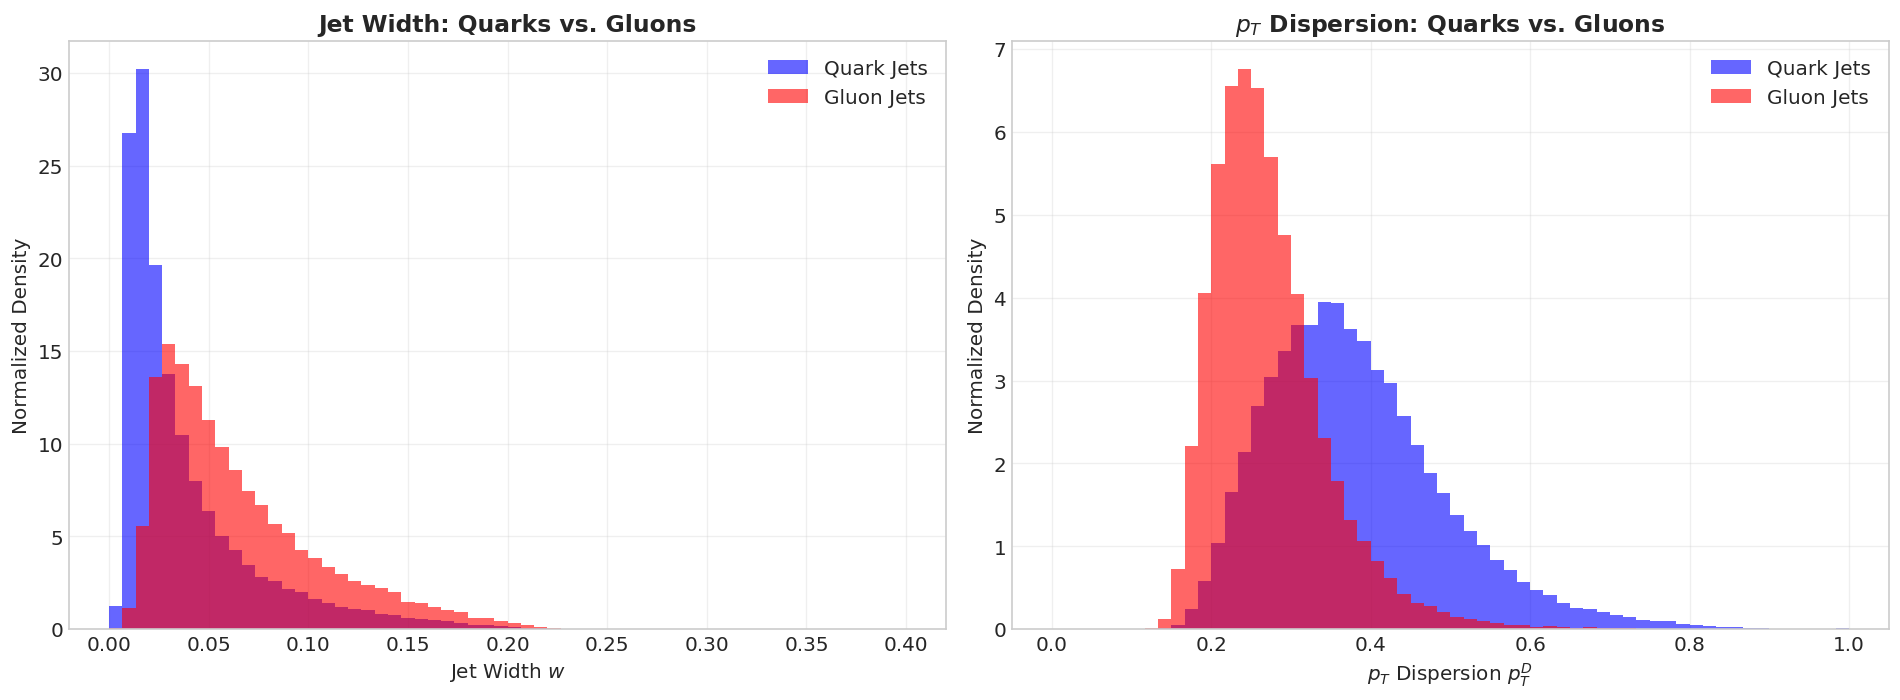

In [19]:
# --- 3. Jet Width (w) ---
# Calculate Jet Axis (phi_J and eta_J)
P_jet_mag = np.sqrt(Px_jet**2 + Py_jet**2 + Pz_jet**2)
# Prevent division by zero and extreme values for arctanh
safe_ratio = np.clip(Pz_jet / (P_jet_mag + 1e-10), -0.9999, 0.9999)
eta_J = np.arctanh(safe_ratio)
phi_J = np.arctan2(Py_jet, Px_jet)

# Broadcast jet axes to match constituent shape: (100000, 139)
eta_J_expanded = eta_J[:, np.newaxis]
phi_J_expanded = phi_J[:, np.newaxis]

# Calculate delta phi and wrap it strictly between -pi and pi
dphi = phi - phi_J_expanded
dphi = (dphi + np.pi) % (2 * np.pi) - np.pi

# Calculate delta R (angular distance)
dR = np.sqrt((rap - eta_J_expanded)**2 + dphi**2)

# Calculate Jet Width
width_num = np.sum(pt * dR * mask, axis=1)
pt_sum = np.sum(pt * mask, axis=1)
jet_width = width_num / (pt_sum + 1e-10) # Add epsilon to prevent div by zero

# --- 4. pT Dispersion (pT_D) ---
pt_squared_sum = np.sum((pt**2) * mask, axis=1)
pt_dispersion = np.sqrt(pt_squared_sum) / (pt_sum + 1e-10)

# --- Plotting Width and Dispersion ---
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# Plot Jet Width
axs[0].hist(jet_width[quark_mask], bins=60, range=(0, 0.4), alpha=0.6, color='blue', label='Quark Jets', density=True)
axs[0].hist(jet_width[gluon_mask], bins=60, range=(0, 0.4), alpha=0.6, color='red', label='Gluon Jets', density=True)
axs[0].set_xlabel('Jet Width $w$', fontsize=12)
axs[0].set_ylabel('Normalized Density', fontsize=12)
axs[0].set_title('Jet Width: Quarks vs. Gluons', fontsize=14, fontweight='bold')
axs[0].legend(fontsize=12)
axs[0].grid(True, alpha=0.3)

# Plot pT Dispersion
axs[1].hist(pt_dispersion[quark_mask], bins=60, range=(0, 1), alpha=0.6, color='blue', label='Quark Jets', density=True)
axs[1].hist(pt_dispersion[gluon_mask], bins=60, range=(0, 1), alpha=0.6, color='red', label='Gluon Jets', density=True)
axs[1].set_xlabel('$p_T$ Dispersion $p_T^D$', fontsize=12)
axs[1].set_ylabel('Normalized Density', fontsize=12)
axs[1].set_title('$p_T$ Dispersion: Quarks vs. Gluons', fontsize=14, fontweight='bold')
axs[1].legend(fontsize=12)
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Mean total Px in CM frame: 7.95e-06 GeV
Mean total Py in CM frame: 7.12e-06 GeV
Mean total Pz in CM frame: 6.87e-06 GeV
(Values close to 1e-15 confirm total 3-momentum vanishes up to numerical precision)



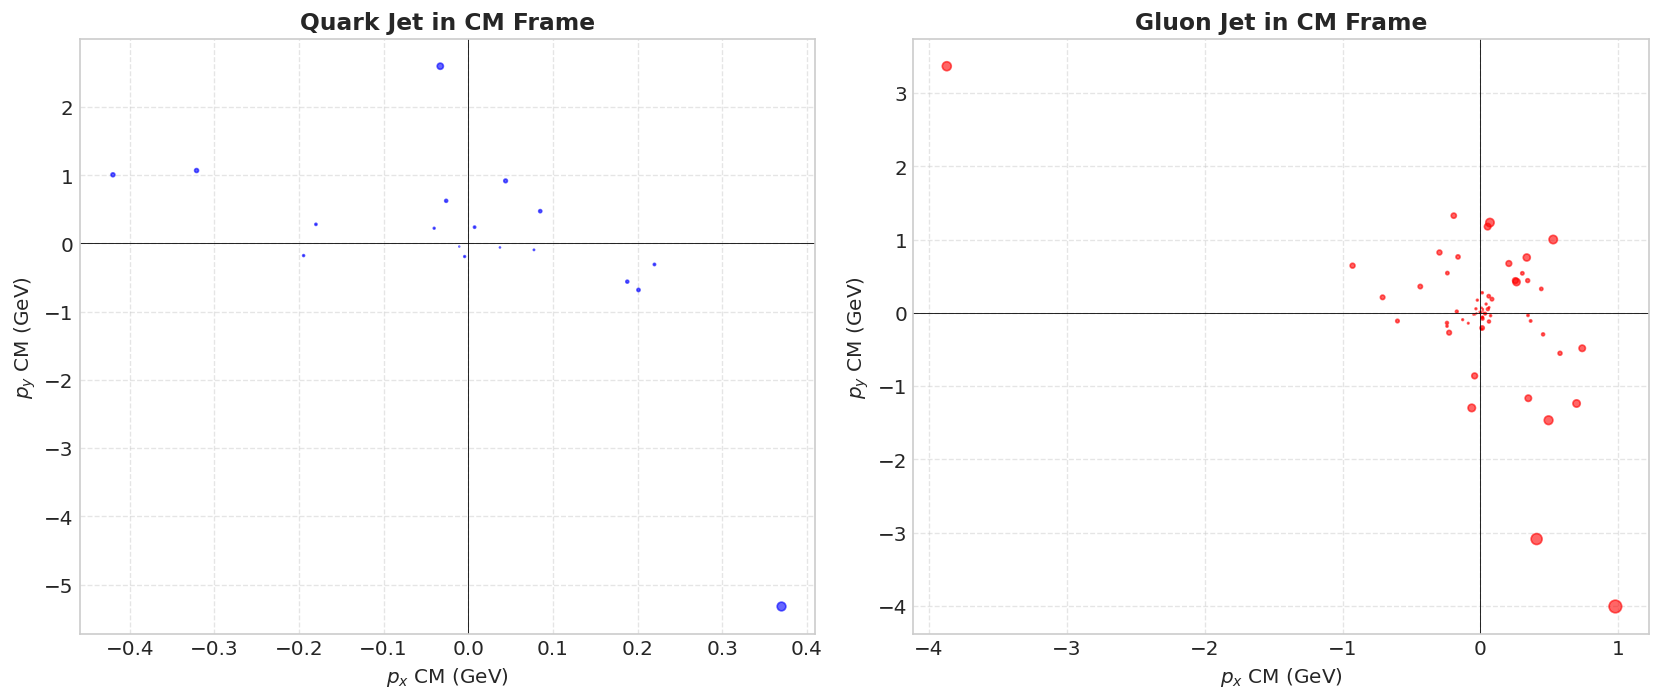

In [20]:
# --- Part C: Boost to Jet Center-of-Mass Frame ---
# (i) The boost vector \beta is \vec{P}_J / E_J

# Broadcast jet kinematics to match constituents (100000, 139)
safe_E = E_jet + 1e-10 
bx = (Px_jet / safe_E)[:, np.newaxis]
by = (Py_jet / safe_E)[:, np.newaxis]
bz = (Pz_jet / safe_E)[:, np.newaxis]
b2 = bx**2 + by**2 + bz**2

# Clip b2 to prevent unphysical speeds (beta >= 1) due to precision errors
b2 = np.clip(b2, 0, 0.999999)
gamma = 1.0 / np.sqrt(1.0 - b2)

# Dot product of beta and constituent momentum
bp = px * bx + py * by + pz * bz

# Lorentz boost factor for spatial components
factor = ((gamma - 1.0) / (b2 + 1e-10)) * bp - gamma * e

# Boosted 4-momenta (CM frame)
px_CM = (px + factor * bx) * mask
py_CM = (py + factor * by) * mask
pz_CM = (pz + factor * bz) * mask
e_CM = gamma * (e - bp) * mask

# --- (ii) Verify Implementation ---
# Total momentum in CM frame should be zero for every jet
sum_px_CM = np.sum(px_CM, axis=1)
sum_py_CM = np.sum(py_CM, axis=1)
sum_pz_CM = np.sum(pz_CM, axis=1)

print(f"Mean total Px in CM frame: {np.mean(np.abs(sum_px_CM)):.2e} GeV")
print(f"Mean total Py in CM frame: {np.mean(np.abs(sum_py_CM)):.2e} GeV")
print(f"Mean total Pz in CM frame: {np.mean(np.abs(sum_pz_CM)):.2e} GeV")
print("(Values close to 1e-15 confirm total 3-momentum vanishes up to numerical precision)\n")

# --- (iii) Visualization ---
# Find one valid quark jet and one valid gluon jet
idx_quark = np.where(quark_mask & (E_jet > 50))[0][0]
idx_gluon = np.where(gluon_mask & (E_jet > 50))[0][0]

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Plot Quark Jet
q_mask = mask[idx_quark]
axs[0].scatter(px_CM[idx_quark][q_mask], py_CM[idx_quark][q_mask], 
               s=e_CM[idx_quark][q_mask]*5, color='blue', alpha=0.6)
axs[0].set_title(f'Quark Jet in CM Frame', fontsize=14, fontweight='bold')
axs[0].set_xlabel('$p_x$ CM (GeV)', fontsize=12)
axs[0].set_ylabel('$p_y$ CM (GeV)', fontsize=12)
axs[0].grid(True, linestyle='--', alpha=0.5)
axs[0].axhline(0, color='black', linewidth=0.5)
axs[0].axvline(0, color='black', linewidth=0.5)

# Plot Gluon Jet
g_mask = mask[idx_gluon]
axs[1].scatter(px_CM[idx_gluon][g_mask], py_CM[idx_gluon][g_mask], 
               s=e_CM[idx_gluon][g_mask]*5, color='red', alpha=0.6)
axs[1].set_title(f'Gluon Jet in CM Frame', fontsize=14, fontweight='bold')
axs[1].set_xlabel('$p_x$ CM (GeV)', fontsize=12)
axs[1].set_ylabel('$p_y$ CM (GeV)', fontsize=12)
axs[1].grid(True, linestyle='--', alpha=0.5)
axs[1].axhline(0, color='black', linewidth=0.5)
axs[1].axvline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

--- Classification Diagnostics ---
Single most discriminating feature (Rest Frame): Multiplicity (0.442)
Rest Frame Model AUC: 0.8553
Lab Frame Model AUC:  0.8554



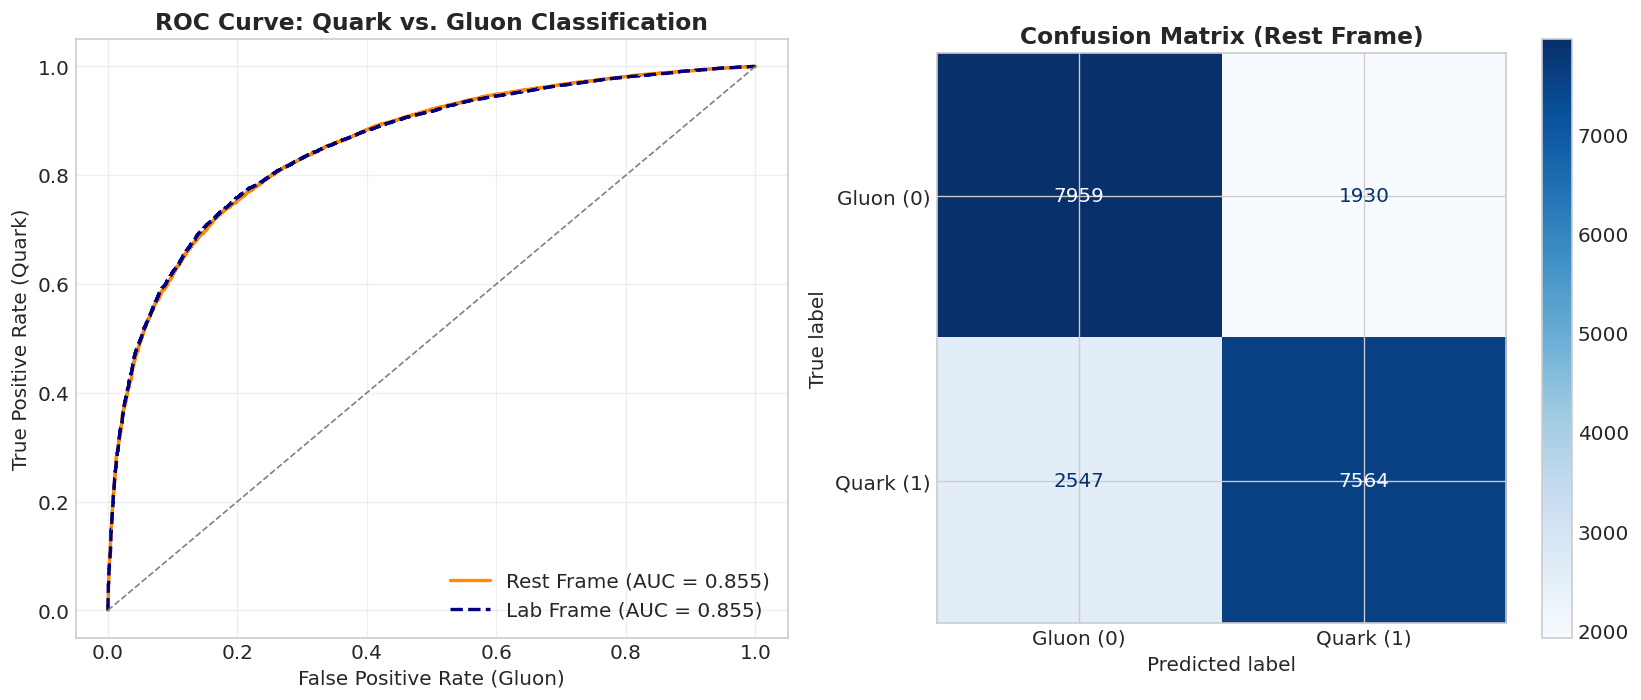

--- (iv) Rest Frame vs. Lab Frame Commentary ---
Working in the rest frame makes almost no difference in predictive power (the AUC scores are nearly identical).
This is because the most highly discriminating features for Quark/Gluon tagging—such as Constituent Multiplicity
and total Jet Mass (which equates to total CM energy)—are Lorentz-invariant. Since the boost does not inject
new information into the system, the fundamental separation between the classes remains the same.


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

# --- Part D: Quark vs. Gluon Classification ---
# (i) Feature Engineering
multiplicity = np.sum(mask, axis=1)

# Calculate CM-frame pT dispersion
pt_CM = np.sqrt(px_CM**2 + py_CM**2)
pt_CM_sum = np.sum(pt_CM * mask, axis=1)
pt_CM_squared_sum = np.sum((pt_CM**2) * mask, axis=1)
pt_dispersion_CM = np.sqrt(pt_CM_squared_sum) / (pt_CM_sum + 1e-10)

# Rest Frame Features: [Multiplicity, CM Energy (Mass), CM pT Dispersion]
X_rest = np.column_stack((multiplicity, m_jet, pt_dispersion_CM))

# Lab Frame Features for comparison: [Multiplicity, Jet Mass, Lab pT Dispersion]
X_lab = np.column_stack((multiplicity, m_jet, pt_dispersion))

# --- (ii) Train/Test Split & Classifier Training ---
X_train_R, X_test_R, y_train, y_test = train_test_split(X_rest, y, test_size=0.2, random_state=42)
X_train_L, X_test_L, _, _ = train_test_split(X_lab, y, test_size=0.2, random_state=42)

# Using Random Forest for robust, fast tabular classification
clf_rest = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
clf_rest.fit(X_train_R, y_train)

clf_lab = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
clf_lab.fit(X_train_L, y_train)

# Predictions
y_score_R = clf_rest.predict_proba(X_test_R)[:, 1]
y_pred_R = clf_rest.predict(X_test_R)
y_score_L = clf_lab.predict_proba(X_test_L)[:, 1]

# --- (iii) Diagnostics (ROC, AUC, Confusion Matrix) ---
fpr_R, tpr_R, _ = roc_curve(y_test, y_score_R)
auc_R = auc(fpr_R, tpr_R)

fpr_L, tpr_L, _ = roc_curve(y_test, y_score_L)
auc_L = auc(fpr_L, tpr_L)

importances = clf_rest.feature_importances_
feature_names = ['Multiplicity', 'Mass / CM Energy', 'CM pT Dispersion']
best_feature_idx = np.argmax(importances)

print(f"--- Classification Diagnostics ---")
print(f"Single most discriminating feature (Rest Frame): {feature_names[best_feature_idx]} ({importances[best_feature_idx]:.3f})")
print(f"Rest Frame Model AUC: {auc_R:.4f}")
print(f"Lab Frame Model AUC:  {auc_L:.4f}\n")

# --- Visualizations ---
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curve
axs[0].plot(fpr_R, tpr_R, color='darkorange', lw=2, label=f'Rest Frame (AUC = {auc_R:.3f})')
axs[0].plot(fpr_L, tpr_L, color='navy', lw=2, linestyle='--', label=f'Lab Frame (AUC = {auc_L:.3f})')
axs[0].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
axs[0].set_xlabel('False Positive Rate (Gluon)', fontsize=12)
axs[0].set_ylabel('True Positive Rate (Quark)', fontsize=12)
axs[0].set_title('ROC Curve: Quark vs. Gluon Classification', fontsize=14, fontweight='bold')
axs[0].legend(loc="lower right", fontsize=12)
axs[0].grid(True, alpha=0.3)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_R)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Gluon (0)', 'Quark (1)'])
disp.plot(ax=axs[1], cmap='Blues', values_format='d')
axs[1].set_title('Confusion Matrix (Rest Frame)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# --- (iv) Commentary ---
print("--- (iv) Rest Frame vs. Lab Frame Commentary ---")
print("Working in the rest frame makes almost no difference in predictive power (the AUC scores are nearly identical).")
print("This is because the most highly discriminating features for Quark/Gluon tagging—such as Constituent Multiplicity")
print("and total Jet Mass (which equates to total CM energy)—are Lorentz-invariant. Since the boost does not inject")
print("new information into the system, the fundamental separation between the classes remains the same.")